# RFdiffusion2 Nature Methods: 4MU-butyrate wetlab analysis

Screening and kinetics for the additional 4MU-butyrate metallohydrolases in Ahern *et al.*, **Nature Methods 23, 96–105 (2026)** ([paper](https://doi.org/10.1038/s41592-025-02975-x)). The shared 4MU-phenylacetate experiments are in [Metallohydrolase_Nature_2026](../Metallohydrolase_Nature_2026/).

All required inputs are included. Publication kinetics use the 2025-04-01 calibration plate. Instrument file-location metadata have been removed from the experimental workbooks; measurement values are unchanged.


In [1]:
from pathlib import Path
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from IPython.display import display

start = Path(os.environ.get("ZINC_HYDRO_REPO", Path.cwd())).resolve()
repo = next((p for p in (start, *start.parents)
             if (p / "Scripts").is_dir() and (p / "LICENSE").exists()), None)
if repo is None:
    raise RuntimeError("Open this notebook inside the cloned repository, or set ZINC_HYDRO_REPO.")
working_dir = repo / "Manuscript_Data" / "Metallohydrolase_RFdiffusion2_Nature_Methods_2026"
raw_dir = working_dir / "raw_wetlab_data"
plots_dir = working_dir / "wetlab_data_plots"
plots_dir.mkdir(exist_ok=True)
sys.path.insert(0, str(repo / "Scripts"))
from experimental_data_processing_functions import (
    parse_kinetics, parse_excels, standard_curve, mm_kinetics,
    draw_progression_curve_v0, draw_progression_curve_seperate_v0, save_figure,
)
import experimental_data_processing_functions as edpf
edpf.FIGURE_DPI, edpf.SAVE_EPS = 150, False
raw_wetlab_data_dir = str(raw_dir) + "/"
pics_dir = str(plots_dir) + "/"
kinetic_summaries = []
initial_rates = []
print("Inputs: raw_wetlab_data/\nFigures and result tables: wetlab_data_plots/")

Inputs: raw_wetlab_data/
Figures and result tables: wetlab_data_plots/


# I. Functional screening data

The published screening uses the **2024-07-10** plate. The original figure excludes H8 and H9 and identifies C4, B11 and D11 as the three strongest progress curves. The file name records the assay preparation; the Methods describes the final reaction mixture. Screening enzyme concentrations were not normalized, so the screen is a hit-finding assay, not a ranking of catalytic efficiencies.

Screen contains all 96 plate positions and 172 time points.


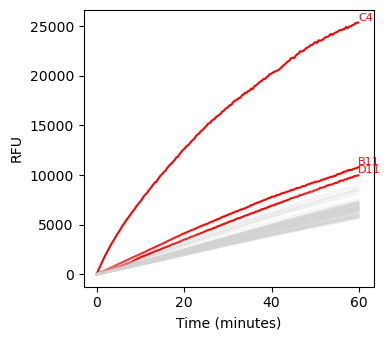

Publication hits: C4, B11, D11


In [2]:
screen_file = str(raw_dir / "240710_zn_hydrolase_96_order1_200uM_zinc_100uM_butyrate.xlsx")
screen = parse_excels(screen_file, None, start_row=48)
assert all(f"{r}{c}" in screen for r in "ABCDEFGH" for c in range(1, 13))
print(f"Screen contains all 96 plate positions and {len(screen)} time points.")
# Preserve the publication notebook's preprocessing exactly: exclude H8/H9
# before hit selection and normalize each included trace to its first reading.
publication_wells = [f"{r}{c}" for r in "ABCDEFGH" for c in range(1, 13)
                     if f"{r}{c}" not in ["H8", "H9"]]
publication_screen = screen.loc[(screen.Time > 0) & (screen.Time < 60), ["Time", *publication_wells]].copy()
publication_screen["Time"] -= publication_screen["Time"].iloc[0]
publication_screen[publication_wells] -= publication_screen[publication_wells].iloc[0]
publication_hits = publication_screen[publication_wells].iloc[-1].nlargest(3).index.tolist()
assert publication_hits == ["C4", "B11", "D11"]
fig, ax = plt.subplots(figsize=(4, 3.5))
for well in publication_wells:
    if well in publication_hits:
        ax.plot(publication_screen.Time, publication_screen[well], color="red")
        ax.text(publication_screen.Time.iloc[-1], publication_screen[well].iloc[-1], well,
                color="red", ha="left", va="bottom", fontsize=8)
    else:
        ax.plot(publication_screen.Time, publication_screen[well], color="lightgray", alpha=0.2)
ax.set(xlabel="Time (minutes)", ylabel="RFU")
left, right = ax.get_xlim()
ax.set_xlim(left, right * 1.01)
fig.tight_layout()
save_figure(str(plots_dir / "4MU_B_published_screen_combined"))
plt.show()
plt.close(fig)
print("Publication hits:", ", ".join(publication_hits))
# Verify the publication's hit identities independently of figure rendering.
window = screen.loc[(screen.Time > 0) & (screen.Time < 60)]
wells = [f"{r}{c}" for r in "ABCDEFGH" for c in range(1, 13) if f"{r}{c}" not in ["H8", "H9"]]
change = window[wells].iloc[-1] - window[wells].iloc[0]
assert list(change.nlargest(3).index) == ["C4", "B11", "D11"]
change.rename("change_RFU").rename_axis("well").to_csv(plots_dir / "screen_signal_changes.csv")

## I.A. All plate positions

This grid retains H8/H9 and shows raw fluorescence for every well so the complete screen can be inspected. The publication's combined plot above preserves its original exclusions.

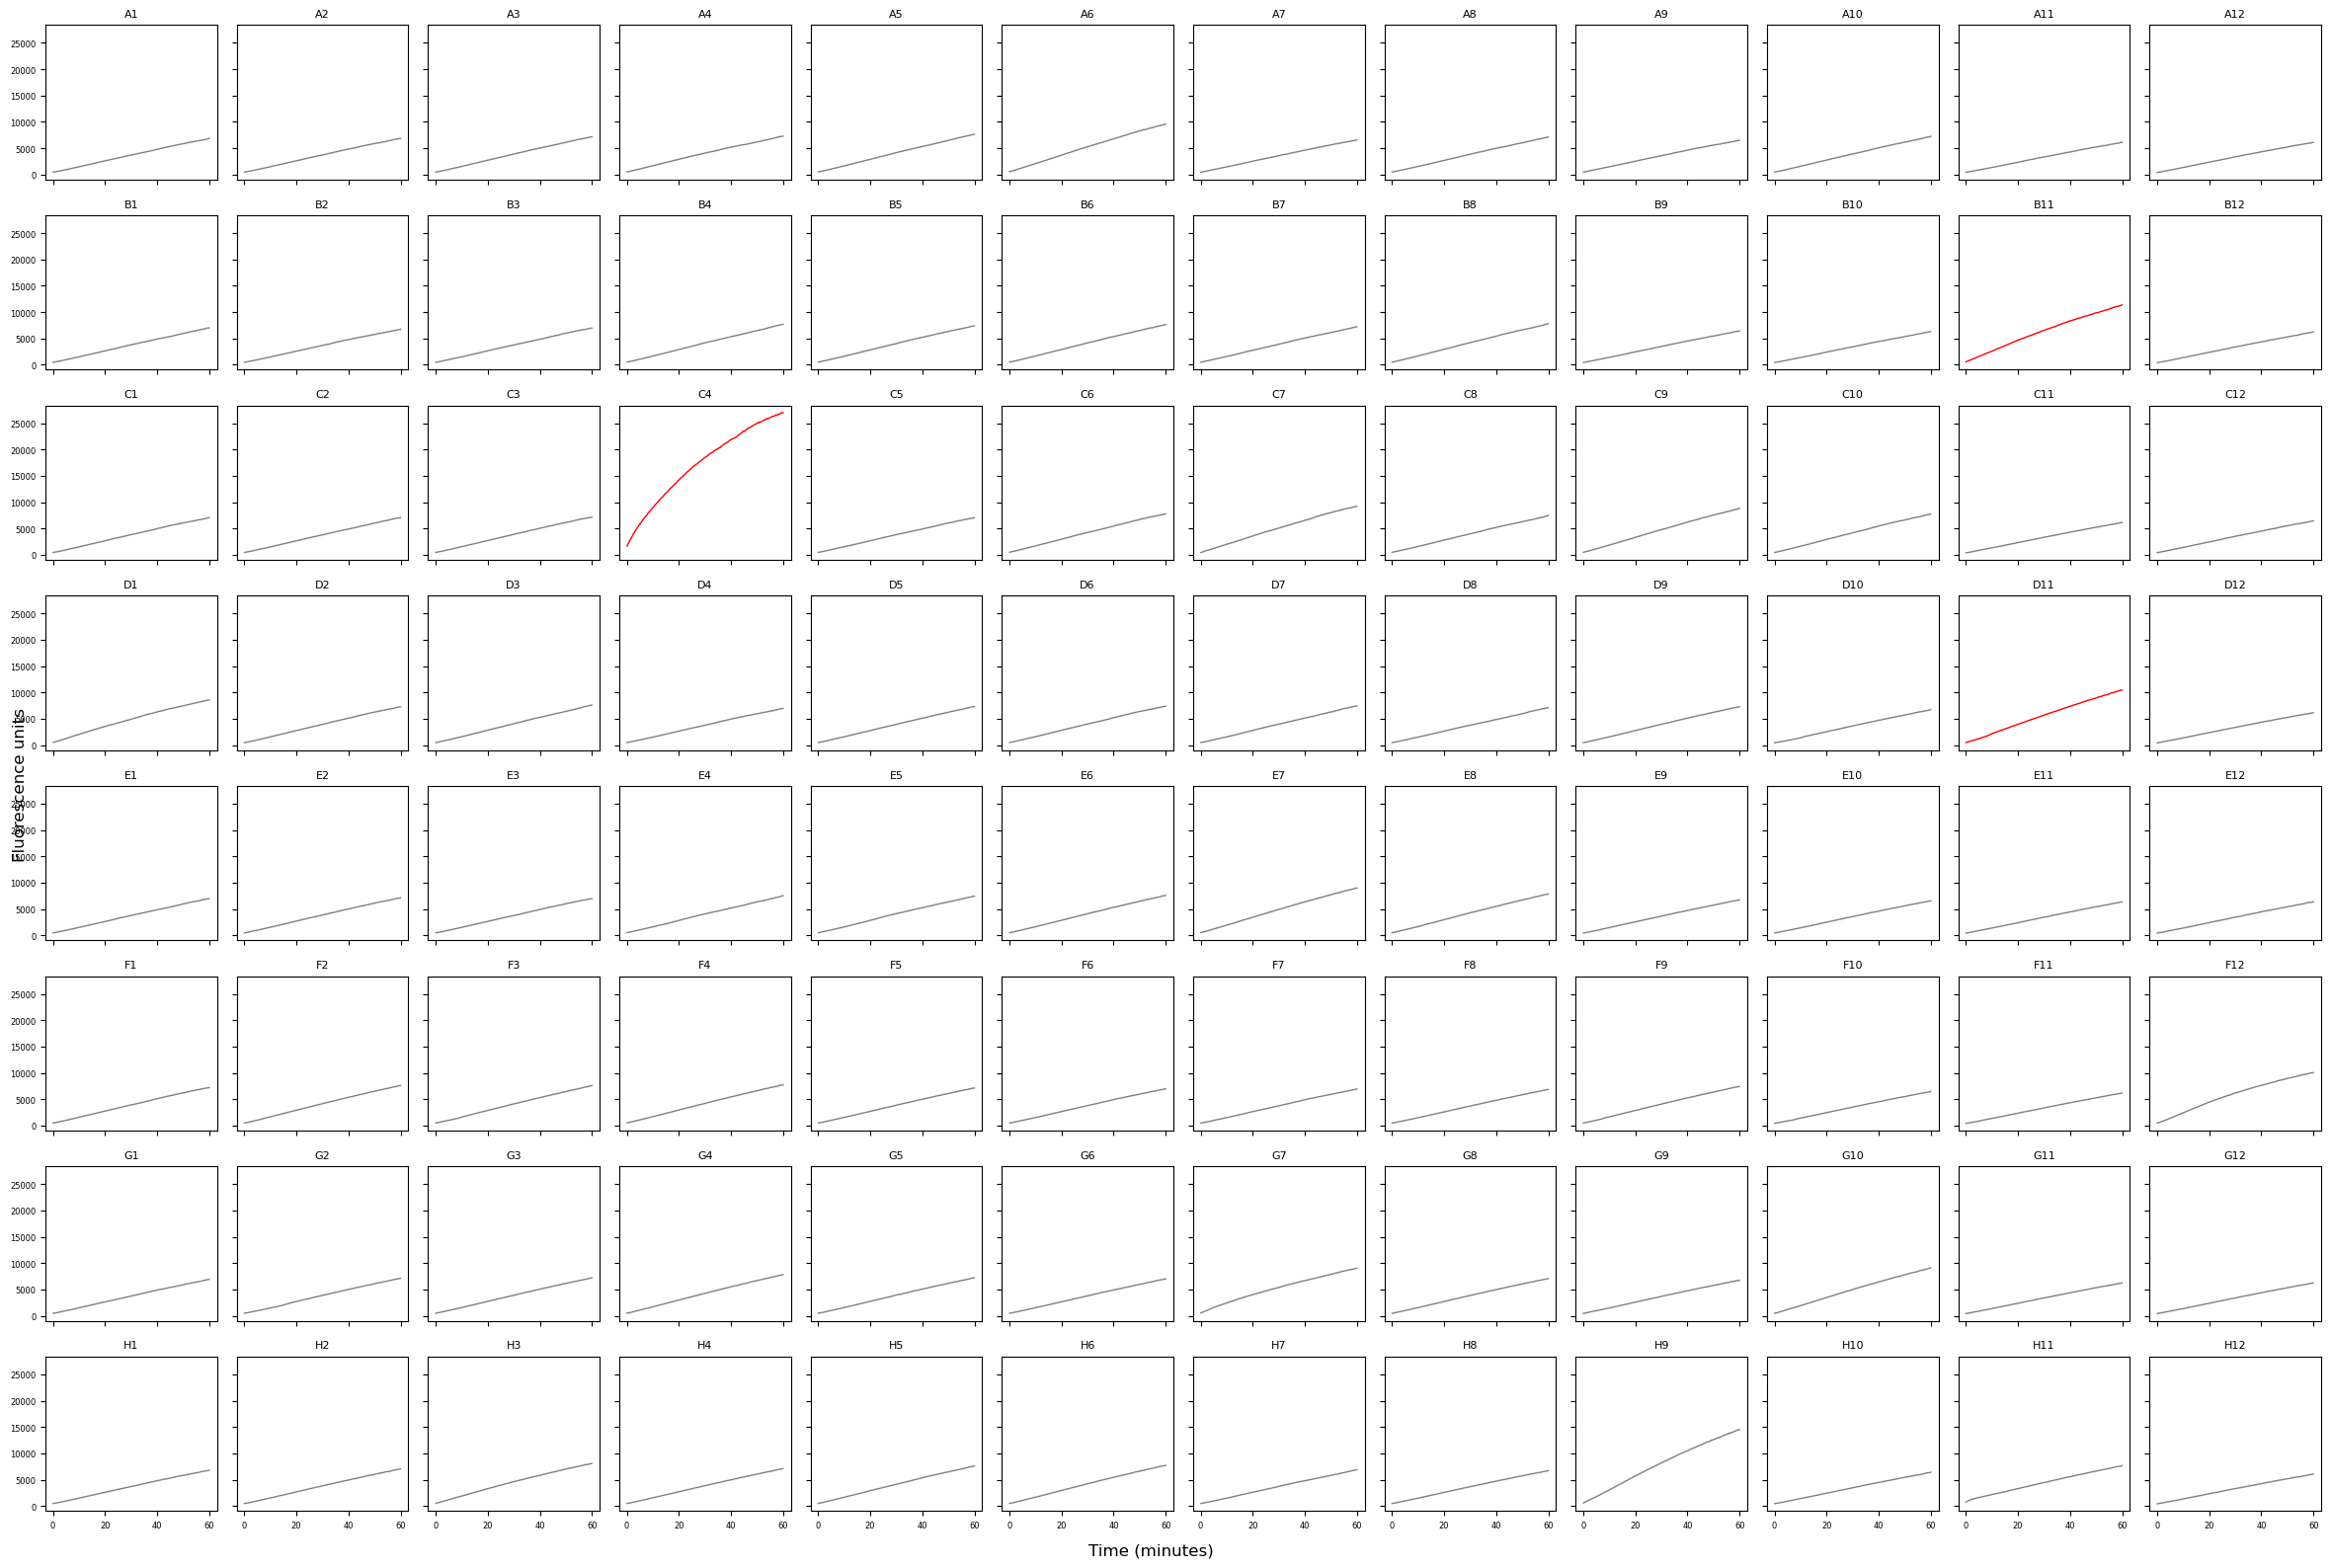

In [3]:
fig, axes = plt.subplots(8, 12, figsize=(24, 16), sharex=True, sharey=True)
for i, row in enumerate("ABCDEFGH"):
    for j, col in enumerate(range(1, 13)):
        well = f"{row}{col}"
        ax = axes[i, j]
        ax.plot(screen.Time, screen[well], color="red" if well in ["C4", "B11", "D11"] else "gray", lw=1)
        ax.set_title(well, fontsize=8)
        ax.tick_params(labelsize=6)
fig.supxlabel("Time (minutes)")
fig.supylabel("Fluorescence units")
fig.tight_layout()
save_figure(str(plots_dir / "4MU_B_screen_all_96_wells"))
plt.show()
plt.close(fig)

## I.B. Archived screening conditions (2024-07-16)

Three additional full-plate screens are included as raw TSV exports. These are not substituted for the 2024-07-10 publication plate. File names identify the original assay conditions; the panels highlight the same three subsequently characterized hits.

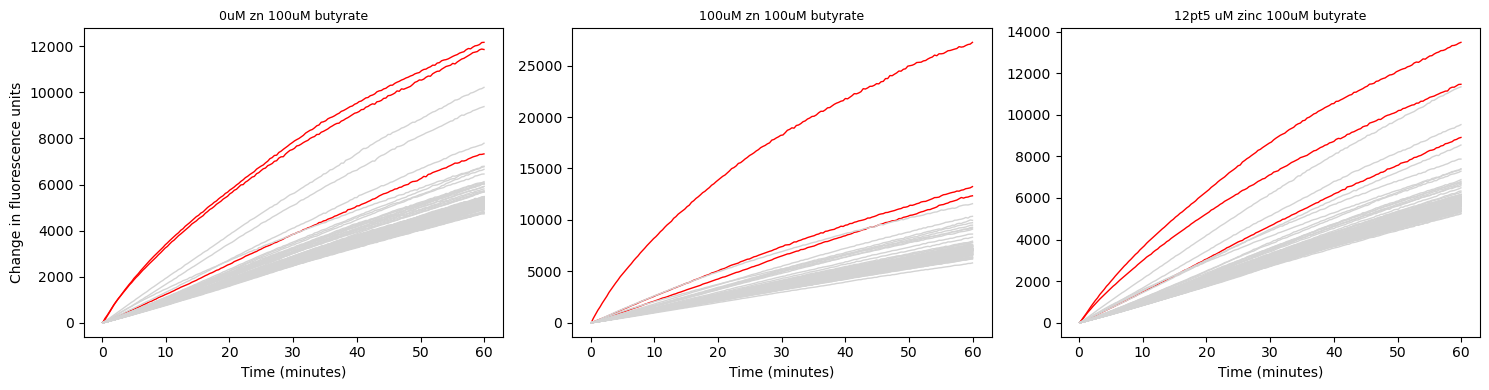

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, filename in zip(axes, sorted(raw_dir.glob("240716*butyrate.tsv"))):
    data = pd.read_csv(filename, sep="\t")
    time_minutes = pd.to_timedelta(data.Time).dt.total_seconds() / 60
    for row in "ABCDEFGH":
        for col in range(1, 13):
            well = f"{row}{col}"
            y = pd.to_numeric(data[well], errors="raise")
            ax.plot(time_minutes, y - y.iloc[0], color="red" if well in ["B11", "C4", "D11"] else "lightgray", lw=1)
    ax.set_title(filename.stem.split("order1_")[-1].split("Order1_")[-1].replace("_", " "), fontsize=9)
    ax.set_xlabel("Time (minutes)")
axes[0].set_ylabel("Change in fluorescence units")
fig.tight_layout()
save_figure(str(plots_dir / "4MU_B_archived_screen_conditions"))
plt.show()
plt.close(fig)

# II. Kinetics

All three publication hits were measured at 3 µM enzyme and 20 µM Zn(II), with 0.77–99 µM 4MU-butyrate. C4 and B11 use 0–200 s; D11 uses 0–300 s. The final publication notebook uses the 2025-04-01 calibration, which is re-derived below from the included plate. Progress curves and Michaelis–Menten fits use the same shared functions as the Nature metallohydrolase notebook.

For D11, the available substrate range does not establish saturation. As stated in the paper's supplementary methods, only the low-substrate estimate of kcat/KM is meaningful; separate kcat and KM are not reported.

Slope: 9.296712951159367e-10, Intercept: -1.1844204142708292e-06


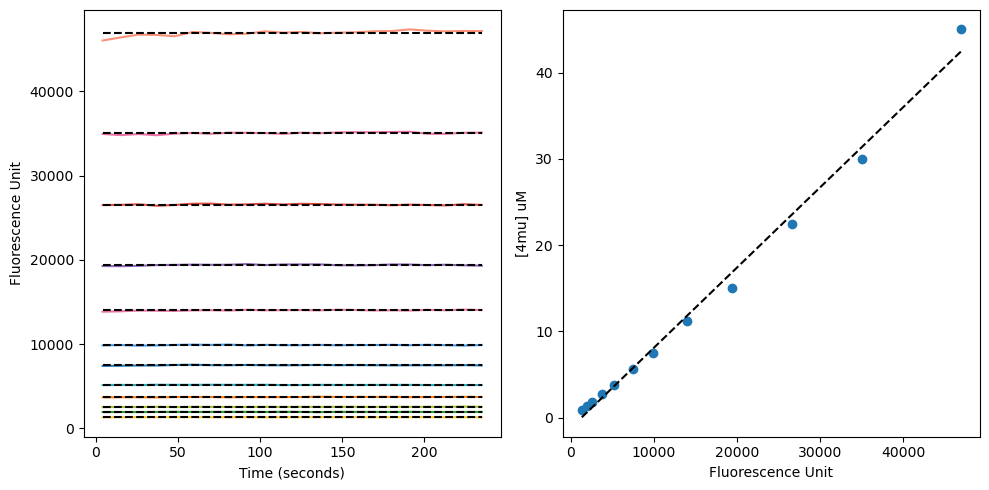

Slope: 9.447803716354774e-10, Intercept: -1.2793396323801954e-06


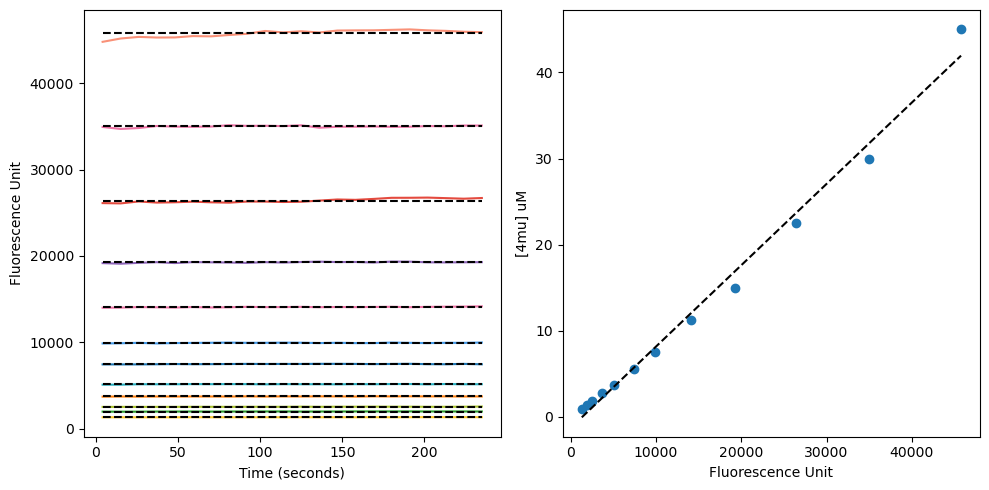

Slope: 9.40363467934009e-10, Intercept: -1.1365045883997506e-06


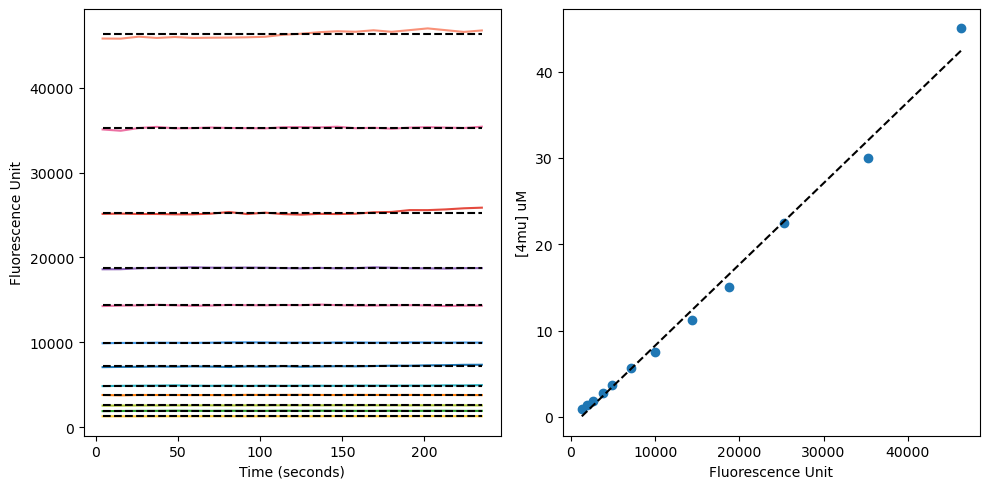

Publication calibration: 9.38271711562e-10 M/FU


In [5]:
calibration_file = str(raw_dir / "250401_4mu_standard_curves_100uL_30uMladder_and_45uMladder_25C_5prctDMSO__pH8.xlsx")
concentrations = [30, 15, 7.5, 3.75, 1.875, 0.9375, 45, 22.5, 11.25, 5.625, 2.8125, 1.40625]
calibration = parse_kinetics(calibration_file, None, start_row=48)
calibration_slopes = []
for row in "DEF":
    _, _, slope = standard_curve(calibration, row, (1, 12), 250000, concentrations, 0, 50000)
    calibration_slopes.append(slope)
SLOPE_4MU_250401 = float(np.mean(calibration_slopes))
np.testing.assert_allclose(calibration_slopes,
    [9.296712951159367e-10, 9.447803716354774e-10, 9.40363467934009e-10], rtol=1e-10)
print(f"Publication calibration: {SLOPE_4MU_250401:.12g} M/FU")

## II.A. C4

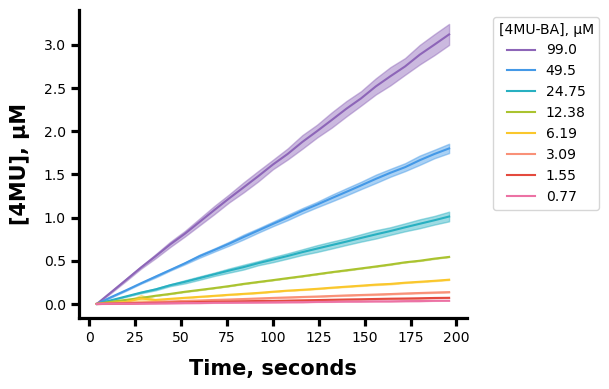

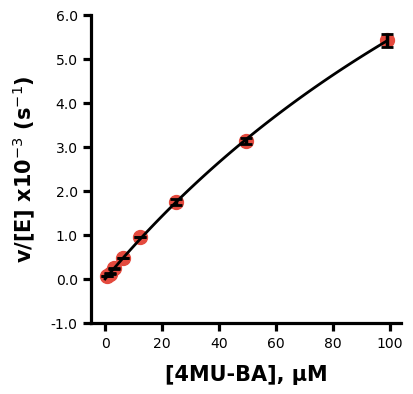

kcat:0.018416±0.001546s⁻¹
Km:238.00±26.36μM
kcat/Km: 77.38 ± 10.75 M⁻¹ s⁻¹

[SUBST] = 99.0uM, v0/[E] = 0.005421716876534271 s⁻¹
[SUBST] = 49.5uM, v0/[E] = 0.0031280234640417123 s⁻¹
[SUBST] = 24.75uM, v0/[E] = 0.0017548086831107245 s⁻¹
[SUBST] = 12.38uM, v0/[E] = 0.0009456295260520466 s⁻¹
[SUBST] = 6.19uM, v0/[E] = 0.00047787701958947114 s⁻¹
[SUBST] = 3.09uM, v0/[E] = 0.00023855758751867417 s⁻¹
[SUBST] = 1.55uM, v0/[E] = 0.00012291760392276583 s⁻¹
[SUBST] = 0.77uM, v0/[E] = 6.461644714452363e-05 s⁻¹


In [6]:
# excel file output from neo2
excel_file = str(raw_dir / '240920_C4_OFFICIAL_kinetics_3uM___butyrate_subst_25C_4min_20uM_zn.xlsx')

# Standarization slope
slope = SLOPE_4MU_250401

# Time to investigate
start_time = 0
end_time = 200

# What substrate did you use? Important for normalization and for pretty (and accurate) plots.
substrate_name = '4MU-BA'

# - what enzyme concentration did you test? (μΜ) - #
enz_conc = 3

# Well information
rows, cols = list("ABCDEFGH"), [5,6,7,8]

# Transpose information
transpose_dic = {"A": 1, 
                 "B": 2,
                 "C": 3,
                 "D": 4,
                 "E": 5,
                 "F": 6,
                 "G": 7,
                 "H": 8,
                 5: "A",
                 6: "B",
                 7: "C",
                 8: "D",
                 }

# make a directory for cute pics
pics_dir = str(plots_dir) + '/' 
os.makedirs(pics_dir, exist_ok=True)


rename_dic = {}
for key in transpose_dic:
    value = transpose_dic[key]
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

# specify rows and columns where measurements were taken
row_column_ranges = {
    'A': (1, 8),
}

# rows containing replicates
replicate_rows = ['B', 'C']

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# - what substrate concentrations did you test in those specific wells? (μM) - #
sub_concs = np.array([99, 49.5, 24.75, 12.38, 6.19, 3.09, 1.55, 0.77])

# which row is background?
bg_row = 'D'

# plotting stuff
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, active_wells=active_wells, bg_well_id=bg_row, replicate_rows=replicate_rows, enz_conc=enz_conc, sub_concs=sub_concs, substrate_name=substrate_name, pics_dir=pics_dir, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True)


results_C4 = (kinetic_data.copy(), np.array(v0_enz), start_time, end_time)


## II.B. B11

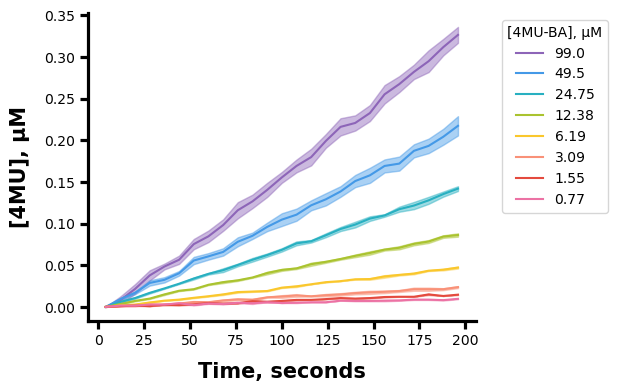

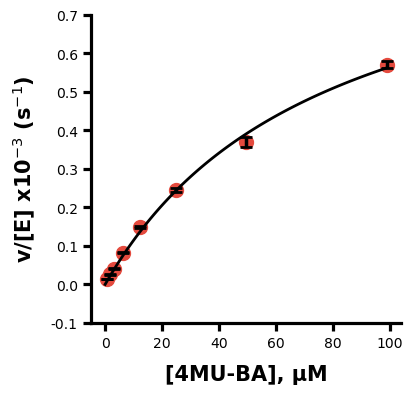

kcat:0.001004±0.000043s⁻¹
Km:77.65±6.00μM
kcat/Km: 12.93 ± 1.14 M⁻¹ s⁻¹

[SUBST] = 99.0uM, v0/[E] = 0.0005709222976526836 s⁻¹
[SUBST] = 49.5uM, v0/[E] = 0.0003704268649288833 s⁻¹
[SUBST] = 24.75uM, v0/[E] = 0.0002457850864934184 s⁻¹
[SUBST] = 12.38uM, v0/[E] = 0.00014983277000763182 s⁻¹
[SUBST] = 6.19uM, v0/[E] = 8.201858059827681e-05 s⁻¹
[SUBST] = 3.09uM, v0/[E] = 4.0999266028715744e-05 s⁻¹
[SUBST] = 1.55uM, v0/[E] = 2.5962860394712416e-05 s⁻¹
[SUBST] = 0.77uM, v0/[E] = 1.4154269836808465e-05 s⁻¹


In [7]:
# excel file output from neo2
excel_file = str(raw_dir / '240920_B11_OFFICIAL_kinetics_3uM___butyrate_subst_25C_4min_20uM_zn.xlsx')

# Standarization slope
slope = SLOPE_4MU_250401

# Time to investigate
start_time = 0
end_time = 200

# What substrate did you use? Important for normalization and for pretty (and accurate) plots.
substrate_name = '4MU-BA'

# - what enzyme concentration did you test? (μΜ) - #
enz_conc = 3

# Well information
rows, cols = list("ABCDEFGH"), [1,2,3,4]

# Transpose information
transpose_dic = {"A": 1, 
                 "B": 2,
                 "C": 3,
                 "D": 4,
                 "E": 5,
                 "F": 6,
                 "G": 7,
                 "H": 8,
                 1: "A",
                 2: "B",
                 3: "C",
                 4: "D",
                 }

# make a directory for cute pics
pics_dir = str(plots_dir) + '/' 
os.makedirs(pics_dir, exist_ok=True)


rename_dic = {}
for key in transpose_dic:
    value = transpose_dic[key]
    if key in rows:
        for col in cols:
            rename_dic[f"{key}{col}"] = f"{transpose_dic[col]}{value}"
    elif key in cols:
        for row in rows:
            rename_dic[f"{row}{key}"] = f"{value}{transpose_dic[row]}"

# specify rows and columns where measurements were taken
row_column_ranges = {
    'A': (1, 8),
}

# rows containing replicates
replicate_rows = ['B', 'C']

# Create an empty list to store active wells
active_wells = []

# Iterate through rows/columns, append to active wells
for row, (start_col, end_col) in row_column_ranges.items():
    for col in range(start_col, end_col + 1):
        active_wells.append(f"{row}{col}")

# - what substrate concentrations did you test in those specific wells? (μM) - #
sub_concs = np.array([99, 49.5, 24.75, 12.38, 6.19, 3.09, 1.55, 0.77])

# which row is background?
bg_row = 'D'

# plotting stuff
bn = os.path.basename(f'{excel_file}').replace('.xlsx','')
kinetic_data = parse_kinetics(excel_file, active_wells, start_row=48)
kinetic_data.rename(columns=rename_dic, inplace=True)
v0_enz = mm_kinetics(kinetic_data, bn, active_wells=active_wells, bg_well_id=bg_row, replicate_rows=replicate_rows, enz_conc=enz_conc, sub_concs=sub_concs, substrate_name=substrate_name, pics_dir=pics_dir, fit_type='straight_line', slope=slope,
            cutoff_start_time=start_time, cutoff_end_time=end_time, plate_type='full', y_ax_mm_intv=0.1, x_ax_mm_intv=50, legend_label=f'[{substrate_name}], μM', norm_zero=True)


results_B11 = (kinetic_data.copy(), np.array(v0_enz), start_time, end_time)


## II.C. D11: unsaturated substrate range

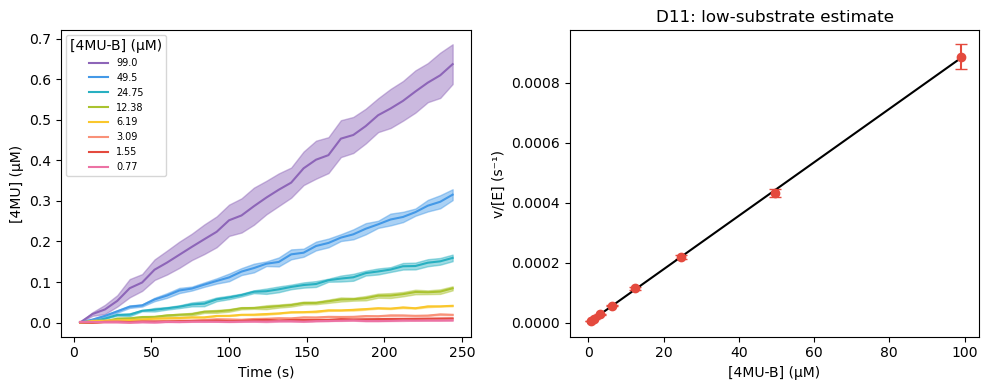

,design,model,kcat_per_s,kcat_fit_sd,KM_uM,KM_fit_sd,kcat_over_KM_Minv_sinv,efficiency_fit_sd
0,C4,Michaelis-Menten,0.018416,0.001546,237.995504,26.356133,77.380224,10.754307
1,B11,Michaelis-Menten,0.001004,0.000043,77.649271,6.003721,12.927256,1.144592
2,D11,low-substrate linear limit,NaN,NaN,NaN,NaN,8.915591,0.116601


Kinetic analysis complete.


In [8]:
sub_concs = np.array([99, 49.5, 24.75, 12.38, 6.19, 3.09, 1.55, 0.77])
file = raw_dir / "240920_D11_OFFICIAL_kinetics_3uM___butyrate_subst_25C_4min_20uM_zn.xlsx"
data_D11 = parse_kinetics(str(file), None, start_row=48)
rename = {f"{row}{col}": f"{'ABCD'[col-9]}{i+1}" for i, row in enumerate("ABCDEFGH") for col in [9,10,11,12]}
data_D11 = data_D11.rename(columns=rename)
results_D11 = (data_D11, None, 0, 300)

# Reproduce all three sets of replicate initial rates and export a compact table.
reference_rates = {
    "C4": [5.421716876534271e-3,3.128023464041712e-3,1.7548086831107241e-3,9.456295260520466e-4,4.778770195894712e-4,2.385575875186742e-4,1.2291760392276585e-4,6.461644714452363e-5],
    "B11": [5.709222976526836e-4,3.704268649288834e-4,2.4578508649341836e-4,1.4983277000763182e-4,8.201858059827681e-5,4.099926602871574e-5,2.5962860394712416e-5,1.4154269836808468e-5],
    "D11": [8.872122009141482e-4,4.3166489041829593e-4,2.192663641355908e-4,1.1444644868848663e-4,5.661893868771548e-5,2.785494143699116e-5,1.3940607363202706e-5,6.6366329060403384e-6],
}
for name, (data, helper_rates, start, end) in {"C4": results_C4, "B11": results_B11, "D11": results_D11}.items():
    selected = data.loc[(data.Time >= start) & (data.Time <= end)]
    rates = []
    traces = []
    for col, substrate in enumerate(sub_concs, 1):
        replicate_traces = []
        for row in "BCA":  # same replicate ordering as the original helper
            y = (selected[f"{row}{col}"] - selected[f"D{col}"]) * SLOPE_4MU_250401 * 1e6
            rate = linregress(selected.Time, y).slope / 3.0
            rates.append(rate)
            replicate_traces.append((y-y.min()).to_numpy(float))
            initial_rates.append(dict(design=name, substrate_uM=substrate, replicate=row,
                                      v_over_E_per_s=rate, start_s=start, end_s=end))
        traces.append(np.array(replicate_traces))
    rates = np.array(rates).reshape(8,3)
    means = rates.mean(axis=1)
    np.testing.assert_allclose(means, reference_rates[name], rtol=1e-10, atol=1e-14)
    if helper_rates is not None:
        np.testing.assert_allclose(means, helper_rates, rtol=1e-10)
        def mm(s, kcat, km): return kcat*s/(km+s)
        (kcat, km), covariance = curve_fit(mm, np.repeat(sub_concs,3), rates.ravel())
        kcat_sd, km_sd = np.sqrt(np.diag(covariance))
        efficiency = kcat/km*1e6
        efficiency_sd = efficiency*np.sqrt((kcat_sd/kcat)**2+(km_sd/km)**2)
        kinetic_summaries.append(dict(design=name, model="Michaelis-Menten", kcat_per_s=kcat,
            kcat_fit_sd=kcat_sd, KM_uM=km, KM_fit_sd=km_sd,
            kcat_over_KM_Minv_sinv=efficiency, efficiency_fit_sd=efficiency_sd))
    else:
        x = np.repeat(sub_concs,3)*1e-6
        efficiency = float(np.dot(x,rates.ravel())/np.dot(x,x))
        residual = rates.ravel()-efficiency*x
        efficiency_sd = float(np.sqrt(np.sum(residual**2)/(len(x)-1)/np.dot(x,x)))
        kinetic_summaries.append(dict(design=name, model="low-substrate linear limit", kcat_per_s=np.nan,
            kcat_fit_sd=np.nan, KM_uM=np.nan, KM_fit_sd=np.nan,
            kcat_over_KM_Minv_sinv=efficiency, efficiency_fit_sd=efficiency_sd))
        fig, axes = plt.subplots(1,2,figsize=(10,4))
        colors = [edpf.good_purple, edpf.good_blue, edpf.good_teal, edpf.good_green,
                  edpf.good_yellow, edpf.good_peach, edpf.good_red, edpf.good_pink]
        for substrate, traces_i, color in zip(sub_concs,traces,colors):
            mean, sd = traces_i.mean(axis=0),traces_i.std(axis=0)
            axes[0].plot(selected.Time,mean,label=f"{substrate}",color=color)
            axes[0].fill_between(selected.Time,mean-sd,mean+sd,color=color,alpha=0.45)
        axes[0].set(xlabel="Time (s)",ylabel="[4MU] (µM)")
        axes[0].legend(title="[4MU-B] (µM)",fontsize=7)
        axes[1].errorbar(sub_concs,means,yerr=rates.std(axis=1,ddof=1)/np.sqrt(3),fmt="o",color=edpf.good_red,capsize=4)
        axes[1].plot([0,99],efficiency*np.array([0,99])*1e-6,color="black")
        axes[1].set(xlabel="[4MU-B] (µM)",ylabel="v/[E] (s⁻¹)",title="D11: low-substrate estimate")
        fig.tight_layout()
        save_figure(str(plots_dir / "D11_progress_and_low_substrate_fit"))
        plt.show()
        plt.close(fig)

kinetics_summary = pd.DataFrame(kinetic_summaries)
kinetics_summary.to_csv(plots_dir / "kinetics_summary.csv",index=False)
pd.DataFrame(initial_rates).to_csv(plots_dir / "kinetics_initial_rates.csv",index=False)
display(kinetics_summary)
print("Kinetic analysis complete.")

## II.D. Additional experimental inputs

The 2024-09-20 standard curve and exploratory C10/E10 experiments are included in `raw_wetlab_data/`. Publication fits use the three characterized hits and the 2025-04-01 calibration.

The 96 ordered sequences and transition-state model archive are in `supplemental_data/`; see the [dataset overview](README.md).
